# <h1 style="text-align: center;">Model Fitness — Predicción de Cancelación y Estrategia de Retención de Clientes</h1>

## Problema del proyecto

La cadena de gimnasios Model Fitness enfrenta una alta tasa de cancelación de clientes. Muchos usuarios dejan de asistir y abandonan su membresía, lo que afecta la estabilidad del negocio. Por ello, es necesario identificar con anticipación qué clientes tienen mayor probabilidad de cancelar y qué características influyen en esa decisión, para diseñar estrategias de retención más efectivas. 



### Objetivo del proyecto
Analizar la información de clientes de Model Fitness para detectar patrones de cancelación, predecir qué usuarios tienen mayor riesgo de irse y segmentarlos en grupos que ayuden a tomar decisiones de retención.

- Revisar y preparar los datos para el análisis.
- Identificar diferencias entre los clientes que cancelan y los que permanecen.
- Construir modelos para predecir la cancelación.
- Comparar el rendimiento de los modelos con métricas clave.
- Agrupar clientes con características similares para detectar perfiles de riesgo.
- Proponer acciones prácticas para mejorar la retención.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado predictivo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

## Limpeza de datos 

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/gym_churn_us.csv')

# Vista rápida
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Verificacion inicial
print(df.info())
print()
print(df.duplicated().sum()) 

# Se estandarizan los nombres de las  y se borran posibles espacios en blanco
df.columns= df.columns.str.lower().str.strip() 
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
# Se estandarizan los nombres de las columnas 
df.columns= df.columns.str.lower().str.strip()

# Redondeo a 1 decimal
df= df.round(1)
print(df.head(5))

   gender  near_location  partner  promo_friends  phone  contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   group_visits  age  avg_additional_charges_total  month_to_end_contract  \
0             1   29                          14.2                    5.0   
1             1   31                         113.2                   12.0   
2             0   28                         129.4                    1.0   
3             1   33                          62.7                   12.0   
4             0   26                         198.4                    1.0   

   lifetime  avg_class_frequency_total  avg_class_frequency_current_month  \
0  

### Conclusión 

No se encontraron valores nulos y los tipos de datos están correctamente asignados. Además, se estandarizaron los nombres de las columnas para facilitar el acceso a la información y se redondearon los valores numéricos para mejorar la legibilidad del análisis. Por otra parte, la base de datos no incluye especificaciones detalladas sobre algunas variables binarias, como género o teléfono, por lo que estas se analizarán únicamente como grupos codificados, sin atribuirles una categoría específica.

## Analisis exploratorio de datos 

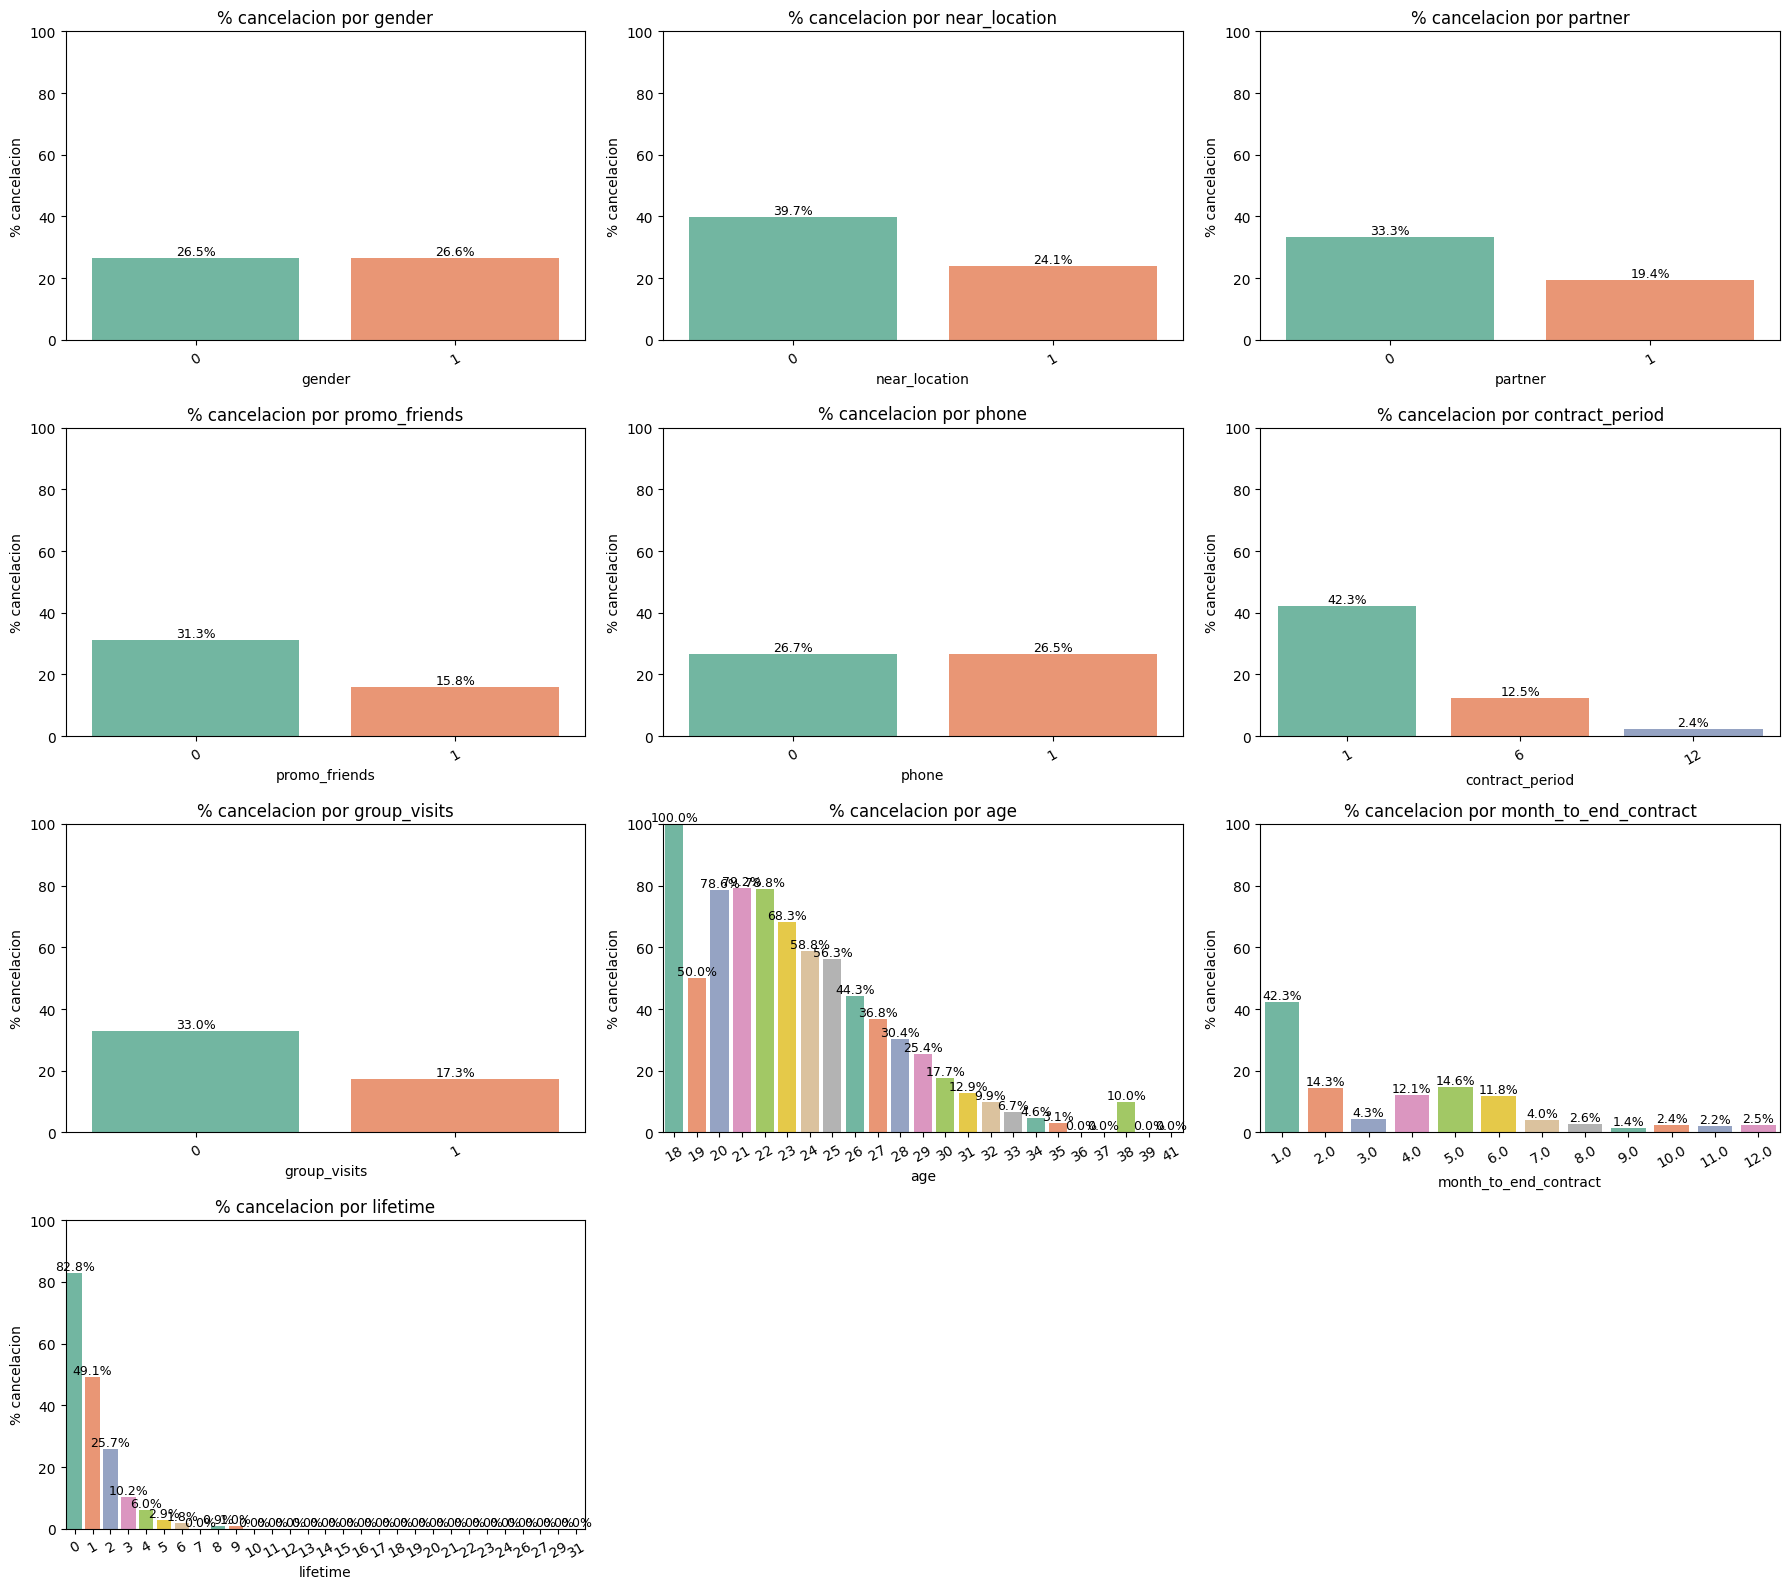

In [ ]:
# Columnas a graficar
cols = [c for c in df.columns if c not in [
    'churn',
    'avg_class_frequency_total',
    'avg_class_frequency_current_month',
    'avg_additional_charges_total'
]]

# Menos columnas y mas espacio para evitar graficas amontonadas
ncols = 2
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]

    # Porcentaje de cancelacion por grupo de la variable
    tmp = (
        df.groupby(col, dropna=False)['churn']
          .mean()
          .mul(100)
          .reset_index(name='cancel_pct')
    )
    tmp['_grupo'] = tmp[col].astype(str)

    sns.barplot(
        data=tmp,
        x=col,
        y='cancel_pct',
        hue='_grupo',
        palette='Set2',
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(f'% cancelacion por {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('% cancelacion')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Etiquetas de porcentaje en cada barra
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(
            f'{h:.1f}%',
            (p.get_x() + p.get_width() / 2, h),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Borra ejes vacios si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.45, wspace=0.25)
plt.show()

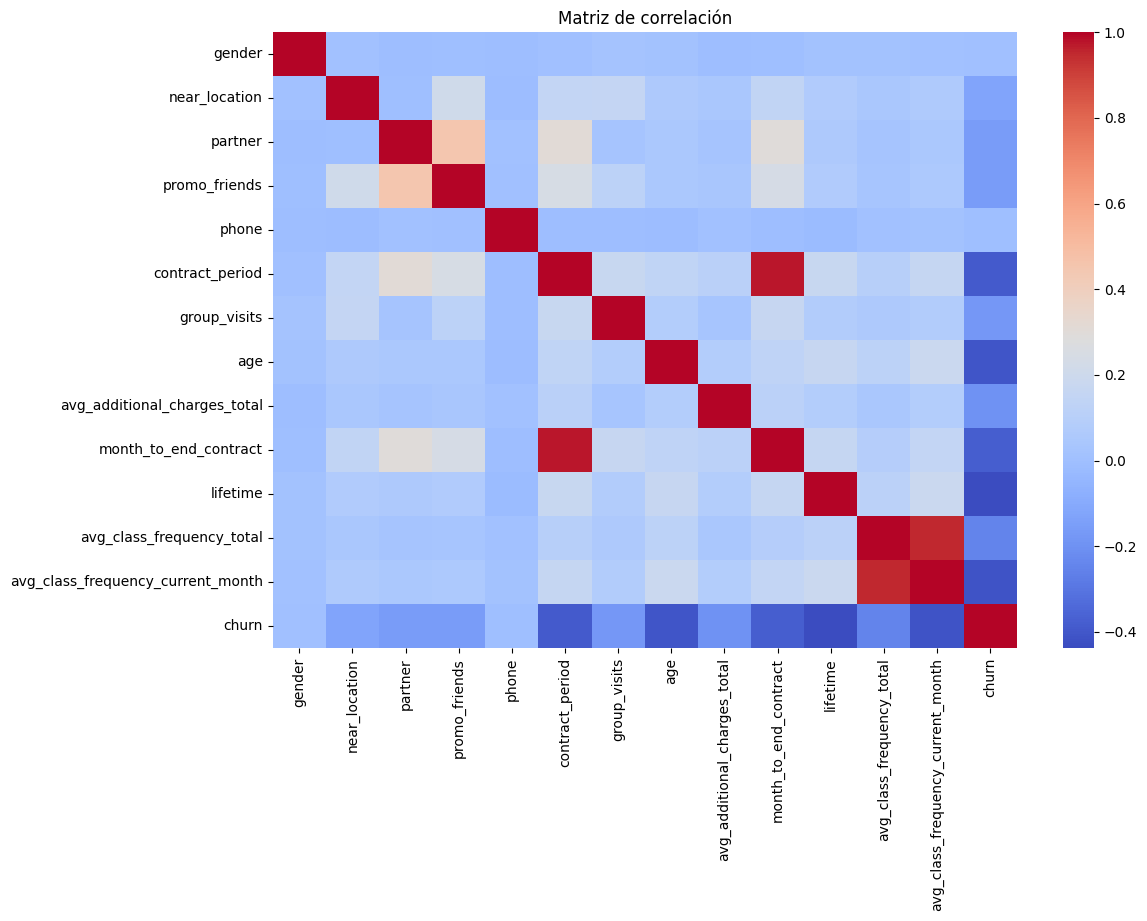

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de correlación')
plt.show()

In [7]:
# Separar variables
X = df.drop('churn', axis=1)   # características
y = df['churn']                # objetivo

# Dividir datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Modelo 1: Regresión Logística
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=0)  # crear modelo
logreg.fit(X_train, y_train)                                # entrenar
pred_log = logreg.predict(X_test)                           # predecir

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Regresión Logística:")
print("Accuracy:", accuracy_score(y_test, pred_log))
print("Precision:", precision_score(y_test, pred_log))
print("Recall:", recall_score(y_test, pred_log))


# Modelo 2: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0)   # crear modelo
rf.fit(X_train, y_train)                      # entrenar
pred_rf = rf.predict(X_test)                  # predecir

# Métricas
print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))

Regresión Logística:
Accuracy: 0.92625
Precision: 0.8638743455497382
Recall: 0.8333333333333334

Random Forest:
Accuracy: 0.92125
Precision: 0.8497409326424871
Recall: 0.8282828282828283


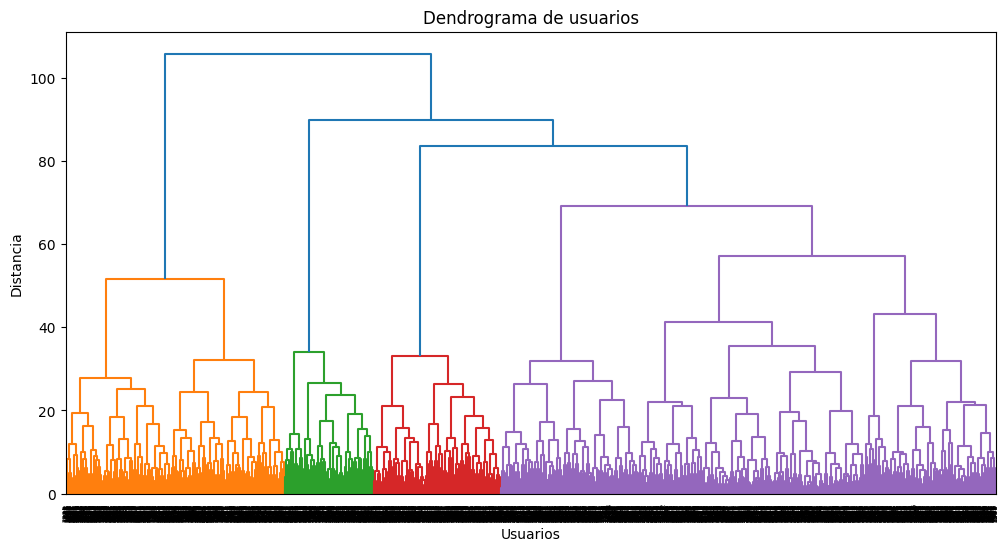

In [8]:
# 4.1 Quitar la columna Churn
X_clust = df.drop('churn', axis=1)

# 4.2 Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# 4.3 Dendrograma
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrograma de usuarios')
plt.xlabel('Usuarios')
plt.ylabel('Distancia')
plt.show()

In [9]:
# 4.4 K-Means con n=5
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# Guardar el clúster en el dataframe
df['cluster'] = clusters

# 4.5 Medias por clúster
print("\n=== Medias por clúster ===")
print(df.groupby('cluster').mean())


=== Medias por clúster ===
           gender  near_location   partner  promo_friends     phone  \
cluster                                                               
0        0.484238       1.000000  0.241681       0.007881  0.903678   
1        0.594886       0.970390  0.290713       0.121131  0.890983   
2        0.496324       0.000000  0.465074       0.077206  0.917279   
3        0.500532       0.943557  0.742279       0.490948  0.899894   
4        0.484177       1.000000  0.799051       1.000000  0.911392   

         contract_period  group_visits        age  \
cluster                                             
0               1.994746      0.327496  28.235552   
1               2.905787      0.483176  30.332436   
2               2.209559      0.213235  28.481618   
3              11.865815      0.551651  29.920128   
4               3.075949      0.446203  29.060127   

         avg_additional_charges_total  month_to_end_contract  lifetime  \
cluster                     

In [10]:
# 4.6 Distribuciones por clúster
for col in ['Age', 'Avg_class_frequency_total', 'Avg_additional_charges_total']:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='cluster', y=col)
    plt.title(f'{col} por clúster')
    plt.show()

ValueError: Could not interpret value `Age` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [ ]:
# 4.7 Tasa de cancelación por clúster
print("\n=== Tasa de churn por clúster ===")
print(df.groupby('cluster')['Churn'].mean())

## Conclusiones principales

La frecuencia de visitas es el factor más importante para predecir churn.  
Los clientes que dejan de asistir reducen su frecuencia semanas antes de abandonar.
Los contratos cortos (1 mes) tienen la mayor tasa de cancelación.  
Los contratos largos funcionan como un ancla de retención.
Los clientes nuevos (Lifetime bajo) son los más vulnerables.  
Si no se enganchan en los primeros meses, es muy probable que se vayan.
El gasto en servicios adicionales está asociado con mayor lealtad.  
Quien consume cafetería, masajes o productos suele estar más comprometido.

# Recomendaciones para retención

Programa de activación para nuevos clientes

Seguimiento durante las primeras 4 semanas
Rutinas guiadas
Recordatorios automáticos si bajan su frecuencia
Objetivo: evitar que los nuevos desaparezcan.

# Incentivar contratos más largos

Descuentos por renovación anticipada
Bonos por pasar de 1 mes → 3 o 6 meses
Objetivo: reducir la rotación de contratos mensuales.

# Aumentar la frecuencia de visitas
   
Retos semanales
Clases grupales gratuitas para clientes inactivos
Notificaciones cuando la asistencia cae
Objetivo: mantener el hábito activo.

# Promover servicios adicionales
   
Paquetes de masajes
Puntos por consumo en cafetería
Descuentos en productos deportivos
Objetivo: aumentar el compromiso emocional y financiero.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
Buen trabajo Fernando! Respecto a los items BÁSICOs tienes **TODO COMPLETADO**. Tu trabajo cumple los ítems básicos (EDA, matriz de correlación, train/test, entrenar regresión logística y random forest, métricas, estandarizar, dendrograma, K-Means n=5, tasa de churn por cluster). Con esto, podemos dar por aprobado tu proyecto 🏅🏅🏅 
    
**Respecto a los niveles intermedio/avanzado** veo que se encuentran parcialmente completados. Esto se debe a que faltó mostrar importancias/coeficientes de features y justificar la elección de k con método del codo/silhouette (intermedio), y faltan afinamiento de hiperparámetros e impacto económico estimado (avanzado). 

**Como recomendación práctica y si deseas explorar aspectos avanzados** conviene cerrar esos puntos para mejorar tu entrega (ej.: calcular coef_ y feature_importances_, graficar codo y silhouette, GridSearchCV). 🚀
</div>

### Conclusiones y recomendaciones
- Nivel general: en conjunto, tu trabajo se sitúa más en un nivel intermedio: cumple muy bien con el flujo básico y con la segmentación, y hay claros análisis y recomendaciones basadas en los resultados. 🏅

- Fortalezas principales:
  - Buen EDA y visualizaciones: comparaciones por Churn y matriz de correlación están presentes. 📊  
  - Modelado correcto y comparación sencilla: se entrenaron regresión logística y random forest y se reportaron métricas clave (accuracy, precision, recall). 🤖  
  - Clustering ejecutado y perfilado: estandarización, dendrograma, K-Means n=5 y tasas de churn por cluster fueron calculadas y resumidas. 🔍

- Áreas de oportunidad y mejora:
  - Interpretablez de modelos: toma en cuenta que faltó mostrar coeficientes de la regresión o importancias de features del random forest para respaldar afirmaciones sobre qué factores importan. 💡  
  - Justificación del número de clusters y métricas de calidad: sería bueno documentar la elección de k (método del codo y/o silhouette) y reportar silhouette_score para apoyar la elección. 📐  
  - Profundizar recomendaciones con impacto: faltó estimar el posible impacto (p. ej. reducción esperada de churn y valor económico) y hacer ajuste de hiperparámetros para robustecer resultados. 💼

Con estas recomendaciones, vas a lograr una entrega robusta y avanzada. ¡Vas muy bien, sigue afinando esos detalles para llevar el proyecto al siguiente nivel! 🚀✅